## **Literature Review (Flight Delay Prediction Project)**
Flight delay prediction is a well-established problem in aviation analytics because delays affect airline cost, airport capacity, passenger satisfaction, and downstream network efficiency. In U.S. aviation reporting, a flight is typically considered on time if it arrives or departs within 15 minutes of schedule, and official delay reporting separates causes such as carrier, weather, NAS, security, and late aircraft. That makes your dataset highly relevant for operational delay analysis because it contains the same kinds of variables used in official delay reporting and performance monitoring.

Research on flight delays has increasingly moved from simple statistical analysis toward machine learning and explainable AI. A systematic review in Transport Reviews describes flight-delay research as a broad data-science field and shows that modern studies use both operational and contextual variables to understand delays. Recent work also shows that combining multiple sources of information—such as airport data, geography, operations, and weather—improves the ability to explain and predict delays, and explainability tools like SHAP are now being used to identify the most influential factors.

Several recent studies support the importance of weather, schedule, and operational features. For example, one study found that weather features were important for both departure and arrival-delay prediction, while another showed that integrating weather with basic flight features improved prediction performance. Other work emphasizes that spatial and temporal context matters, meaning that delay behavior depends not only on a single flight but also on airport congestion, network position, and time-based patterns.

Your dataset fits this literature very well. It has 4,821 rows and 18 columns, with no missing values, and it includes the core feature groups commonly used in delay studies: day of week, origin airport, scheduled vs. actual departure/arrival times, departure delay, arrival delay, delay-cause minutes (carrier, weather, NAS, security, late aircraft), and distance. The target variable Arr_Del_morethan15 is especially suitable for binary classification because it matches the standard 15-minute delay threshold used in aviation reporting. The columns Cancelled, Diverted, and Top_Carriers are constant in this file, so they add little modeling value and may be removed in analysis.

From the data itself, the strongest relationship is between departure delay and arrival delay, which is expected in delay-propagation research. The cause-based delay variables also show meaningful variation, especially Carrier_Delay and Late_Aircraft_Delay, which aligns with prior work showing that delays often propagate through the network and that operational issues at one point can affect later flights. The dataset also shows airport-level variation, suggesting that delay behavior is not uniform across origins and should be studied with location-aware modeling.
## Sources

1. Bureau of Transportation Statistics – Flight Delays  
https://www.bts.gov/explore-topics-and-geography/topics/airline-time-performance-and-causes-flight-delays

2. Transport Reviews – Flight Delay Prediction Review  
https://www.sciencedirect.com/org/science/article/abs/pii/S0144164722000666

3. Flight Delay Prediction using ML and Weather Features  
https://www.sciencedirect.com/science/article/abs/pii/S0957417423022492

4. Federal Aviation Administration (FAA)  
https://www.faa.gov/data_research/aviation_data_statistics


| Column Name           | Type            | Description                           |
| --------------------- | --------------- | ------------------------------------- |
| `Month`               | Numerical       | Flight ka month                       |
| `DayofMonth`          | Numerical       | Month ka specific day                 |
| `DayOfWeek`           | Numerical       | Week ka day                           |
| `Reporting_Airline`   | Categorical     | Airline code                          |
| `Origin`              | Categorical     | Departure airport                     |
| `Dest`                | Categorical     | Arrival airport                       |
| `CRSDepTime`          | Numerical       | Scheduled departure time              |
| `DepTime`             | Numerical       | Actual departure time                 |
| `DepDelay`            | Numerical       | Departure delay (minutes)             |
| `CRSArrTime`          | Numerical       | Scheduled arrival time                |
| `ArrTime`             | Numerical       | Actual arrival time                   |
| `ArrDelay`            | Numerical       | Arrival delay (minutes)               |
| `Cancelled`           | Binary          | Flight cancelled or not               |
| `Diverted`            | Binary          | Flight diverted or not                |
| `Distance`            | Numerical       | Flight distance                       |
| `Carrier_Delay`       | Numerical       | Delay due to airline                  |
| `Weather_Delay`       | Numerical       | Delay due to weather                  |
| `NAS_Delay`           | Numerical       | Delay due to air traffic system       |
| `Security_Delay`      | Numerical       | Delay due to security                 |
| `Late_Aircraft_Delay` | Numerical       | Delay due to previous aircraft        |
| `Top_Carriers`        | Categorical     | Airline category/group                |
| `Arr_Del_morethan15`  | Binary (Target) | Arrival delay more than 15 min or not |

## **Arr_Del_morethan15 Determination Factors**

| Factor                | Description                                                   |
| --------------------- | ------------------------------------------------------------- |
| `DepDelay`            | Flights departing late are more likely to arrive late         |
| `Carrier_Delay`       | Airline operational issues such as crew or maintenance delays |
| `Weather_Delay`       | Bad weather conditions like storms, fog, or rain              |
| `NAS_Delay`           | Air traffic congestion and airport traffic management delays  |
| `Late_Aircraft_Delay` | Previous aircraft arriving late affects the next flight       |
| `Security_Delay`      | Security-related checks or airport security issues            |
| `Distance`            | Longer flights may have different delay patterns              |
| `Origin`              | Some airports experience higher congestion and delays         |
| `Dest`                | Destination airport traffic can affect arrival time           |
| `CRSDepTime`          | Scheduled departure time influences peak-hour congestion      |
| `DayOfWeek`           | Delay frequency may vary across weekdays and weekends         |
| `Month`               | Seasonal conditions and holiday traffic affect delays         |


# Why `Arr_Del_morethan15` is Considered the Target Variable 
`Arr_Del_morethan15` is considered the target variable because it represents the final outcome that the model is trying to predict. The main objective of the analysis is to determine whether a flight will arrive more than 15 minutes late or not. All other columns such as departure delay, weather delay, carrier delay, and distance are used as input features to predict this variable. Since it contains the final prediction result in the form of 0 and 1, it becomes the dependent or target variable in the dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df=pd.read_csv('flight.csv')
df

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4816,4,LAX,815,845,30,1652,1728,36,1,0,0,2611,30,0,6,0,0,1
4817,5,LAX,815,811,-4,1652,1626,-26,0,0,0,2611,0,0,0,0,0,1
4818,7,LAX,815,809,-6,1652,1619,-33,0,0,0,2611,0,0,0,0,0,1
4819,1,LAX,815,811,-4,1652,1709,17,1,0,0,2611,0,0,17,0,0,1


In [4]:
df.describe()

,DayOfWeek,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
count,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.0,4821.0,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.0
mean,4.153703,1338.688032,1335.738021,22.082141,1502.412777,1468.282099,19.459863,0.322132,0.0,0.0,1549.053516,7.505497,1.382493,6.816013,0.051442,8.968056,1.0
std,2.007099,495.435065,524.024009,68.816913,562.241023,600.535851,71.904659,0.467342,0.0,0.0,914.825705,42.419294,19.499934,24.960025,1.524846,39.956099,0.0
min,1.000000,40.000000,1.000000,-20.000000,5.000000,1.000000,-58.000000,0.000000,0.0,0.0,187.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2.000000,900.000000,857.000000,-4.000000,1131.000000,1053.000000,-11.000000,0.000000,0.0,0.0,740.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,4.000000,1335.000000,1334.000000,0.000000,1549.000000,1538.000000,0.000000,0.000000,0.0,0.0,1438.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,6.000000,1725.000000,1751.000000,20.000000,1937.000000,1943.000000,25.000000,1.000000,0.0,0.0,2475.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,7.000000,2357.000000,2400.000000,1333.000000,2359.000000,2400.000000,1355.000000,1.000000,0.0,0.0,3784.000000,1189.000000,1010.000000,359.000000,68.000000,1333.000000,1.0


In [5]:
# ALL COLUMNS ki Unique Values + Count Check

for col in df.columns:
    
    print("\n===================================================")
    print("COLUMN NAME :", col)
    print("===================================================")
    
    print("\nTotal Unique Values :", df[col].nunique())
    
    print("\nUnique Values :")
    print(df[col].unique())
    
    print("\nValue Counts :")
    print(df[col].value_counts())
    
    print("\n\n")


COLUMN NAME : DayOfWeek

Total Unique Values : 7

Unique Values :
[5 6 1 2 3 4 7]

Value Counts :
DayOfWeek
7    789
5    779
6    701
3    645
2    642
4    639
1    626
Name: count, dtype: int64




COLUMN NAME : Origin_Airport

Total Unique Values : 18

Unique Values :
['BOS' 'JFK' 'LAX' 'DFW' 'SFO' 'ORD' 'EWR' 'IAH' 'MCO' 'LGA' 'ATL' 'LAS'
 'SLC' 'DEN' 'CLT' 'PHX' 'DTW' 'MSP']

Value Counts :
Origin_Airport
LAX    1061
DFW     982
JFK     860
ORD     377
SFO     336
MCO     218
BOS     201
LGA     162
LAS     125
PHX     117
IAH      91
DEN      87
MSP      57
SLC      31
ATL      31
CLT      30
EWR      29
DTW      26
Name: count, dtype: int64




COLUMN NAME : Scheduled_Departure

Total Unique Values : 159

Unique Values :
[ 600  830  900 1245 1130 1110  905  700 2115 1115  815 1230 2300 1500
 1900 1530 2230 1645 1825 1705 2245 2355 2350  828 1430  800  500 1700
 1515 1440 1435  710 1200 1105  750  809  715 2020  950 1215 1210 1206
 1827 1842 1810 1908 1747 1335 2210 1815 1820 1

In [6]:

df.drop(columns=[
    'Cancelled',        # Mostly same values, low variation
    'Diverted',         # Very few diverted flights
    'Top_Carriers',     # Repetitive/constant values
    'Arrival_Time',	     # Final outcome information
      'Arrival_Delay',      # Directly related to target variable (data leakage),      
    'Departure_Time'           # Optional removal to avoid leakage
], inplace=True)


## EDA Reasons for Removing Columns

| Column | Detailed Reason |
|---|---|
| `Cancelled` | During EDA, this column showed almost the same value for most rows because very few flights were cancelled. Since there is no meaningful variation, it does not help in identifying flight delay patterns or trends. |
| `Diverted` | Most flights were not diverted, so the column contains very limited information. Low-variation columns usually provide weak analytical insights and have little impact on prediction models. |
| `Top_Carriers` | This column contains repetitive or constant values and does not provide additional information beyond airline-related features already present in the dataset. Therefore, it becomes redundant for analysis. |
| `ArrDelay` | The target variable `Arr_Del_morethan15` is directly created from `ArrDelay`. Keeping this column would cause data leakage because the model could easily predict the target without learning actual patterns. |
| `ArrTime` | Actual arrival time already reflects the final outcome of the flight. Since delay status can indirectly be identified from this column, it may create biased analysis and unrealistic model performance. |
| `DepTime` | Actual departure time may contain future operational information that is not available before prediction. This can introduce leakage and reduce the fairness of predictive modeling. Scheduled departure time is generally more useful for analysis. |

In [7]:
df.head(2)

,DayOfWeek,Origin_Airport,Scheduled_Departure,Dep_Delay,Scheduled_Arrival,Arr_Del_morethan15,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay
0,5,BOS,600,-6,711,0,187,0,0,0,0,0
1,6,BOS,600,-6,711,0,187,0,0,0,0,0


# Univariate Analysis

# Distribution of Flight Arrival Delays

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\2993848685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


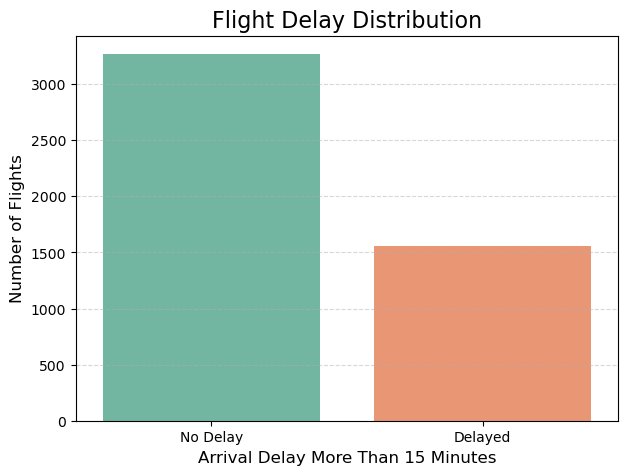

In [8]:
# Count Plot for Target Variable

plt.figure(figsize=(7,5))

sns.countplot(
    x='Arr_Del_morethan15',
    data=df,
    palette='Set2'
)

plt.title('Flight Delay Distribution', fontsize=16)
plt.xlabel('Arrival Delay More Than 15 Minutes', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

plt.xticks([0,1], ['No Delay', 'Delayed'])

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

* The graph shows that around **3,250 flights** arrived on time, while nearly **1,550 flights** were delayed by more than 15 minutes.
* This indicates that the majority of flights in the dataset followed the scheduled arrival time, showing better overall operational performance.
* The dataset is slightly imbalanced because the number of non-delayed flights is much higher than delayed flights.


# Analysis of Flight Departure Delays

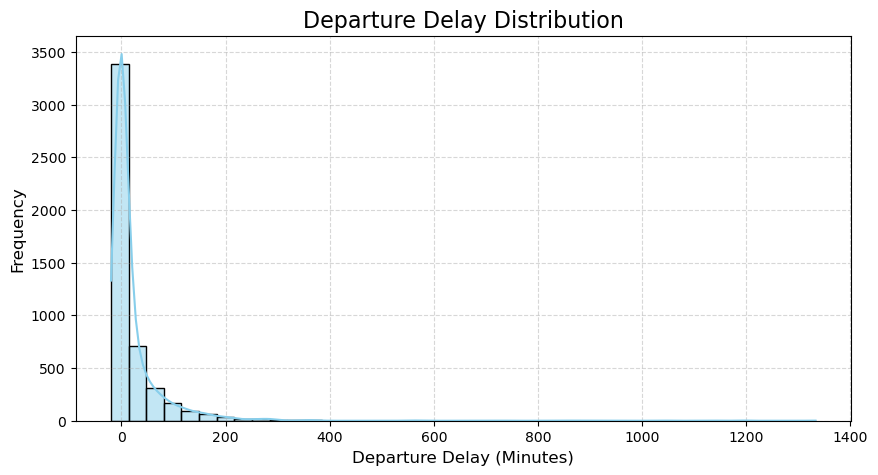

In [9]:
# KDE + Histogram Plot for Departure Delay

plt.figure(figsize=(10,5))

sns.histplot(
    df['Dep_Delay'],
    bins=40,
    kde=True,
    color='skyblue'
)

plt.title('Departure Delay Distribution', fontsize=16)
plt.xlabel('Departure Delay (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(linestyle='--', alpha=0.5)

plt.show()

* The graph shows that most flights had very low departure delays, mainly between **0 to 50 minutes**, with the highest frequency near **0 minutes** delay.
* The distribution is highly right-skewed, meaning only a small number of flights experienced very large delays above **200 minutes**.
* A few extreme outliers reached delays close to **1300 minutes**, indicating rare but severe operational disruptions.


# Exploratory Data Analysis of Flight Delays

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\3854354012.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\3854354012.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


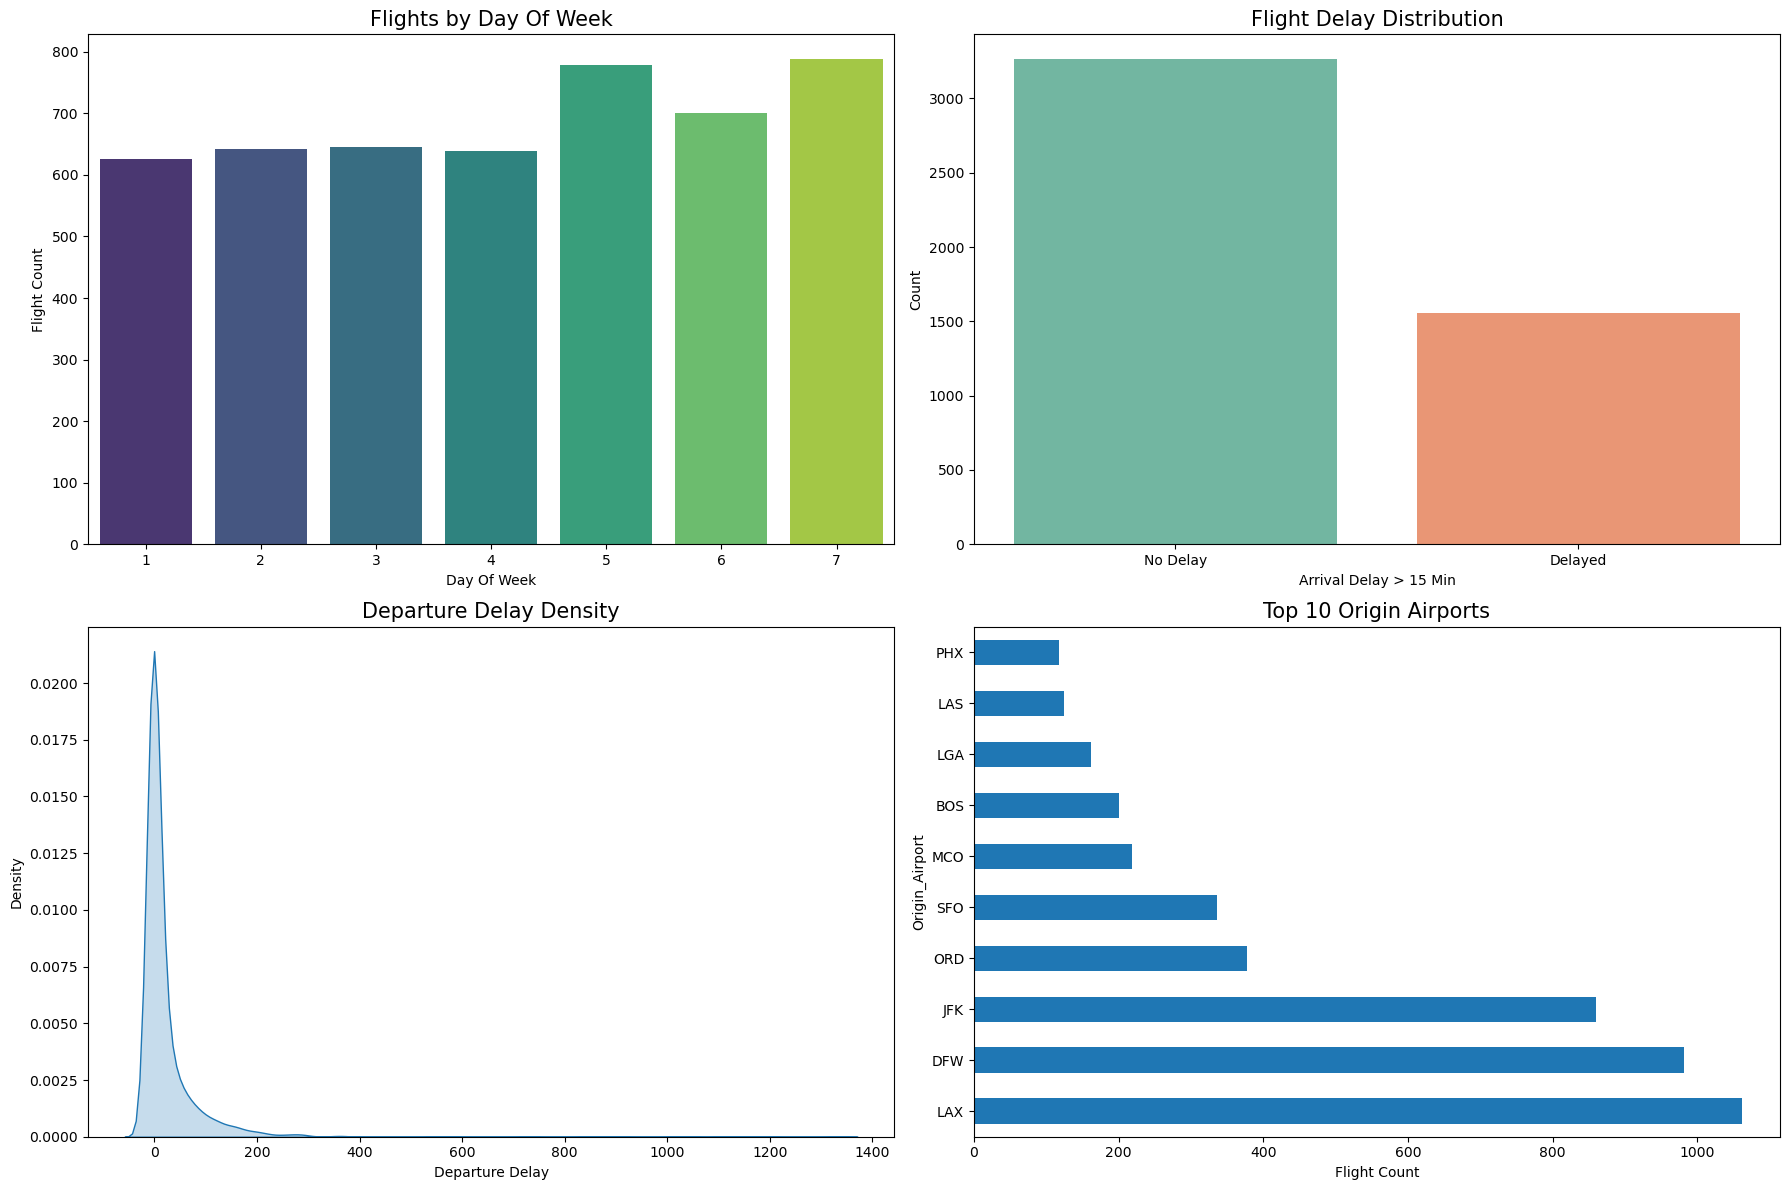

In [10]:
# Create Figure
plt.figure(figsize=(18,12))

# -------------------------------
# 1. Day Of Week Analysis
# -------------------------------

plt.subplot(2,2,1)

sns.countplot(
    x='DayOfWeek',
    data=df,
    palette='viridis'
)

plt.title('Flights by Day Of Week', fontsize=15)
plt.xlabel('Day Of Week')
plt.ylabel('Flight Count')

# -------------------------------
# 2. Target Variable Distribution
# -------------------------------

plt.subplot(2,2,2)

sns.countplot(
    x='Arr_Del_morethan15',
    data=df,
    palette='Set2'
)

plt.title('Flight Delay Distribution', fontsize=15)
plt.xlabel('Arrival Delay > 15 Min')
plt.ylabel('Count')

plt.xticks([0,1], ['No Delay', 'Delayed'])

# -------------------------------
# 3. Departure Delay Distribution
# -------------------------------

plt.subplot(2,2,3)

sns.kdeplot(
    x=df['Dep_Delay'],
    fill=True
)

plt.title('Departure Delay Density', fontsize=15)
plt.xlabel('Departure Delay')

# -------------------------------
# 4. Top Origin Airports
# -------------------------------

plt.subplot(2,2,4)

df['Origin_Airport'].value_counts().head(10).plot(
    kind='barh'
)

plt.title('Top 10 Origin Airports', fontsize=15)
plt.xlabel('Flight Count')

# Adjust Layout
plt.tight_layout()

# Show Graphs
plt.show()

* The analysis shows that flight operations were higher on **Day 5 and Day 7**, with nearly **780–790 flights**, indicating heavier weekend traffic.
* Around **3,250 flights** arrived on time, while approximately **1,550 flights** were delayed by more than 15 minutes, showing that most flights maintained schedule performance.
* The departure delay distribution reveals that most flights experienced delays between **0–50 minutes**, while only a few flights had extreme delays.
* The delay distribution is highly right-skewed, with some rare outliers reaching nearly **1300 minutes** of delay.
* Among origin airports, **LAX** and **DFW** recorded the highest number of flights, making them the busiest airports in the dataset.
* Overall, the graphs indicate that flight delays are generally low, but operational and airport-level factors can still create significant delay patterns in some cases.


# Flight Distance and Delay Factor Analysis Dashboard

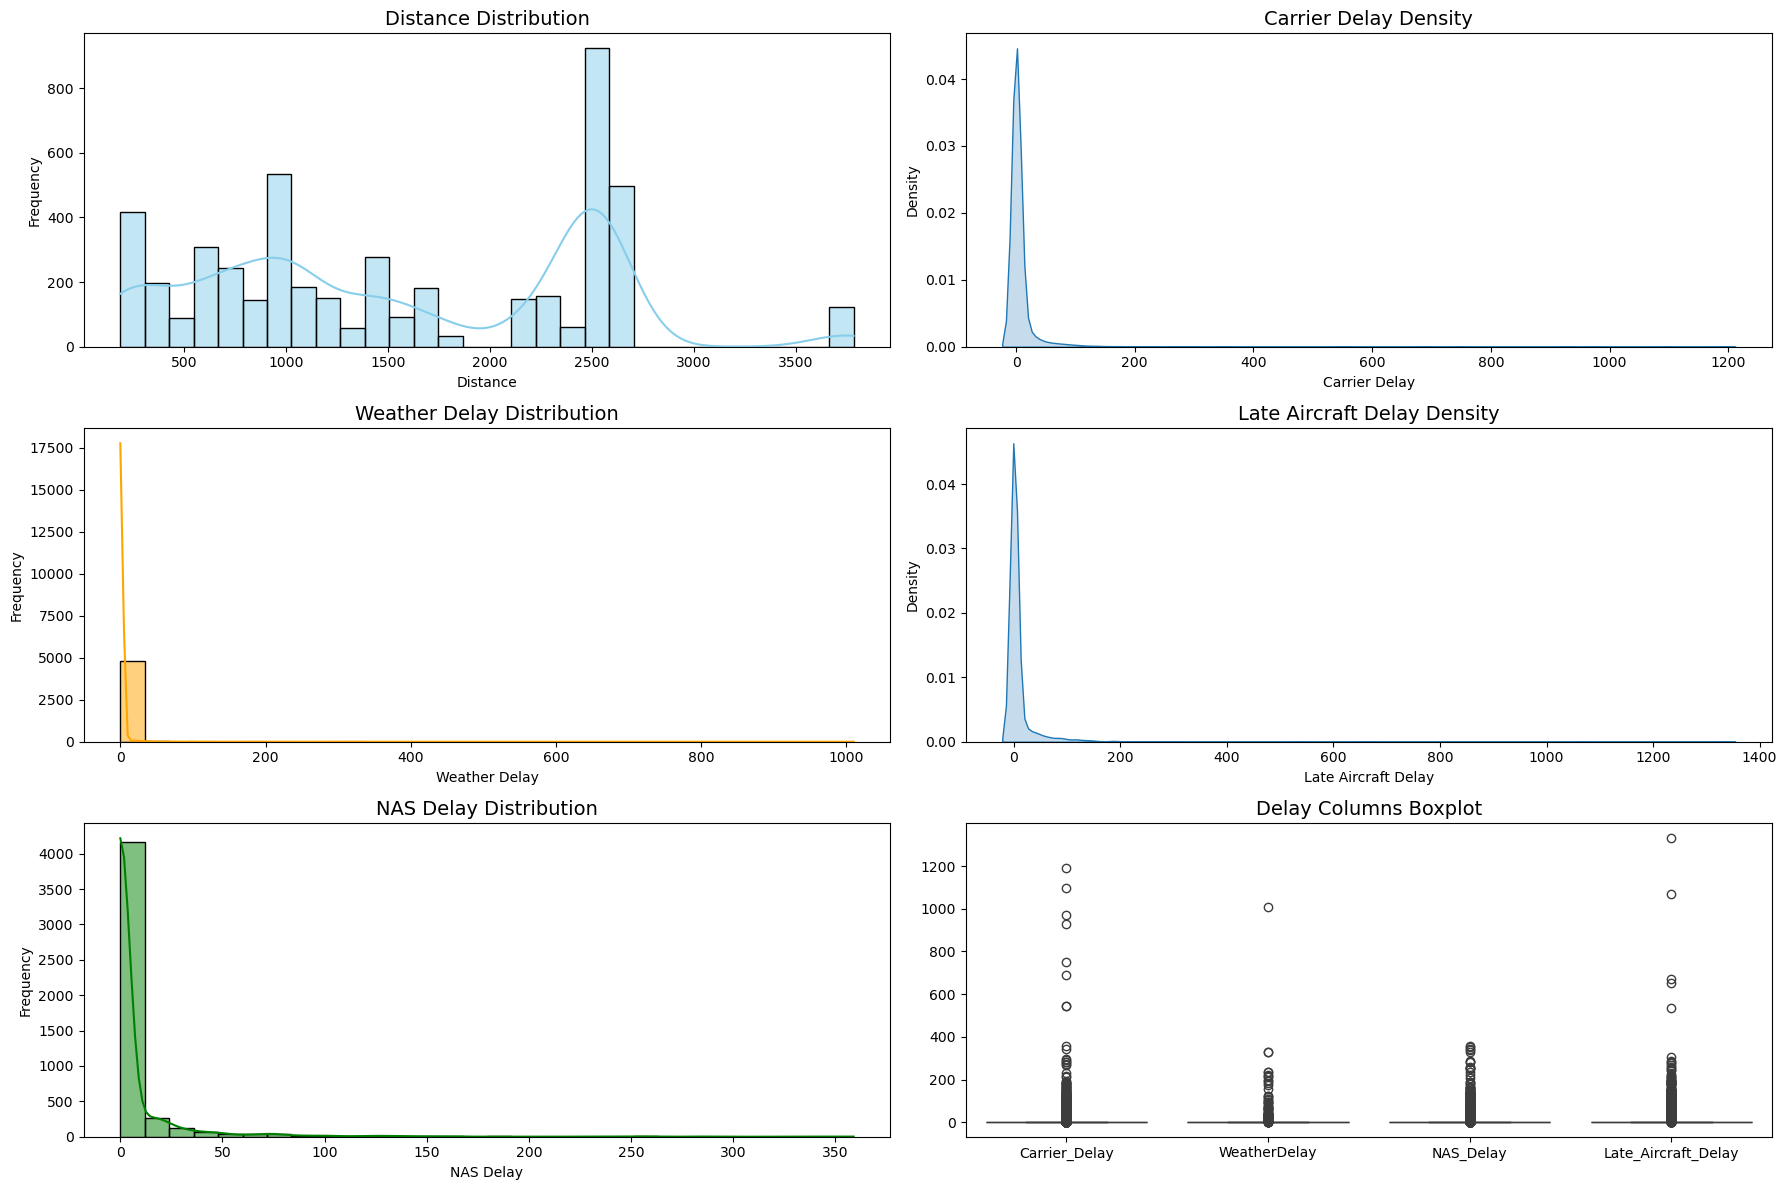

In [11]:
# Create Figure
plt.figure(figsize=(18,12))

# -----------------------------------
# 1. Distance Distribution
# -----------------------------------

plt.subplot(3,2,1)

sns.histplot(
    df['Distance'],
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title('Distance Distribution', fontsize=14)
plt.xlabel('Distance')
plt.ylabel('Frequency')

# -----------------------------------
# 2. Carrier Delay Distribution
# -----------------------------------

plt.subplot(3,2,2)

sns.kdeplot(
    x=df['Carrier_Delay'],
    fill=True
)

plt.title('Carrier Delay Density', fontsize=14)
plt.xlabel('Carrier Delay')

# -----------------------------------
# 3. Weather Delay Distribution
# -----------------------------------

plt.subplot(3,2,3)

sns.histplot(
    df['WeatherDelay'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title('Weather Delay Distribution', fontsize=14)
plt.xlabel('Weather Delay')
plt.ylabel('Frequency')

# -----------------------------------
# 4. Late Aircraft Delay Distribution
# -----------------------------------

plt.subplot(3,2,4)

sns.kdeplot(
    x=df['Late_Aircraft_Delay'],
    fill=True
)

plt.title('Late Aircraft Delay Density', fontsize=14)
plt.xlabel('Late Aircraft Delay')

# -----------------------------------
# 5. NAS Delay Distribution
# -----------------------------------

plt.subplot(3,2,5)

sns.histplot(
    df['NAS_Delay'],
    bins=30,
    kde=True,
    color='green'
)

plt.title('NAS Delay Distribution', fontsize=14)
plt.xlabel('NAS Delay')
plt.ylabel('Frequency')

# -----------------------------------
# 6. Boxplot for Overall Delay Spread
# -----------------------------------

plt.subplot(3,2,6)

sns.boxplot(
    data=df[[
        'Carrier_Delay',
        'WeatherDelay',
        'NAS_Delay',
        'Late_Aircraft_Delay'
    ]]
)

plt.title('Delay Columns Boxplot', fontsize=14)

# Layout
plt.tight_layout()

# Show Graphs
plt.show()

* The graphs show that most flights operated with low delays, while only a small number of flights experienced extremely high delays.
* Flight traffic was higher on **Day 5 and Day 7**, indicating increased weekend flight operations in the dataset.
* Around **3,250 flights** arrived on time, whereas nearly **1,550 flights** were delayed by more than 15 minutes.
* Delay-related features such as **Carrier Delay, NAS Delay, Weather Delay, and Late Aircraft Delay** are highly right-skewed with many outliers.
* Airports like **LAX** and **DFW** had the highest flight counts, showing they were the busiest origin airports in the dataset.


# Bivariate Analysis

## Departure Delay vs Arrival Delay Status

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\761674433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


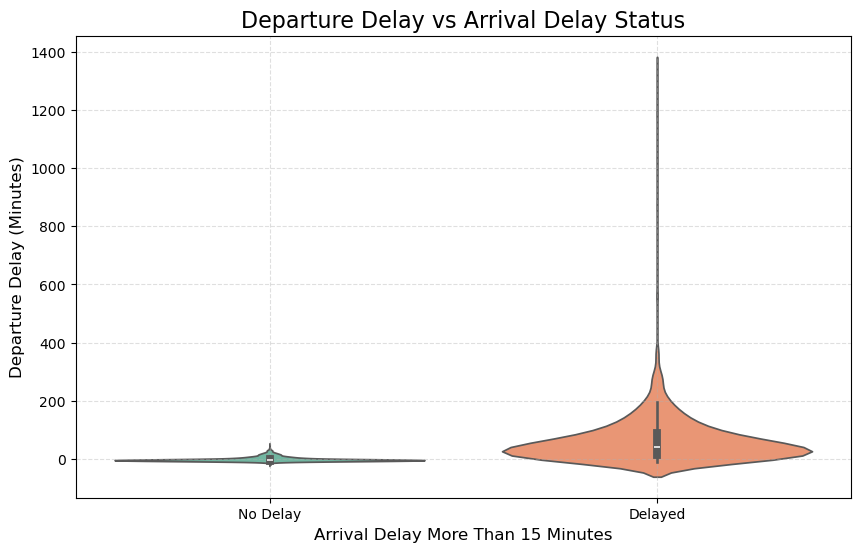

In [12]:
# Bivariate Analysis
# Dep_Delay vs Arr_Del_morethan15

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Arr_Del_morethan15',
    y='Dep_Delay',
    data=df,
    palette='Set2'
)

plt.title('Departure Delay vs Arrival Delay Status', fontsize=16)

plt.xlabel('Arrival Delay More Than 15 Minutes', fontsize=12)
plt.ylabel('Departure Delay (Minutes)', fontsize=12)

plt.xticks([0,1], ['No Delay', 'Delayed'])

plt.grid(linestyle='--', alpha=0.4)

plt.show()

* The graph shows that flights with low departure delays mostly arrived on time.
* Flights in the delayed category had much higher departure delays compared to non-delayed flights.
* Several extreme outliers are visible, with delays reaching nearly **1400 minutes**.
* This indicates a strong relationship between departure delay and arrival delay status.


## Relationship Between Carrier Delay and Departure Delay

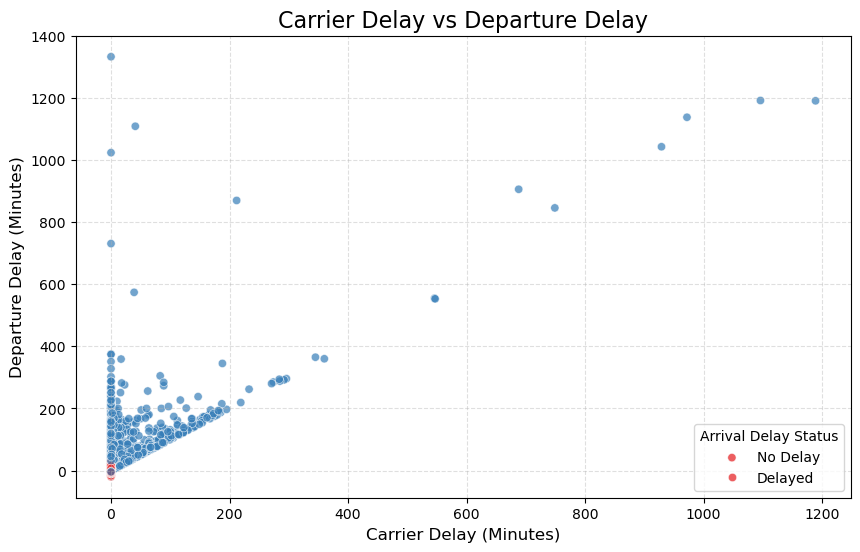

In [13]:
# Scatter Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Carrier_Delay',
    y='Dep_Delay',
    hue='Arr_Del_morethan15',
    data=df,
    palette='Set1',
    alpha=0.7
)

# Title & Labels
plt.title('Carrier Delay vs Departure Delay', fontsize=16)

plt.xlabel('Carrier Delay (Minutes)', fontsize=12)
plt.ylabel('Departure Delay (Minutes)', fontsize=12)

plt.legend(
    title='Arrival Delay Status',
    labels=['No Delay', 'Delayed']
)

plt.grid(linestyle='--', alpha=0.4)

plt.show()

- Most flights have Carrier Delay and Departure Delay below 200 minutes, showing that delays are generally low to moderate.
- The scatter plot indicates a positive relationship, where higher carrier delays often lead to higher departure delays.
- A few extreme outliers are visible, with Carrier Delays above 1,000 minutes and Departure Delays reaching nearly 1,350 minutes, indicating severe disruptions.

## Relationship Between Weather Delays and Flight Arrival Performance

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\787950863.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


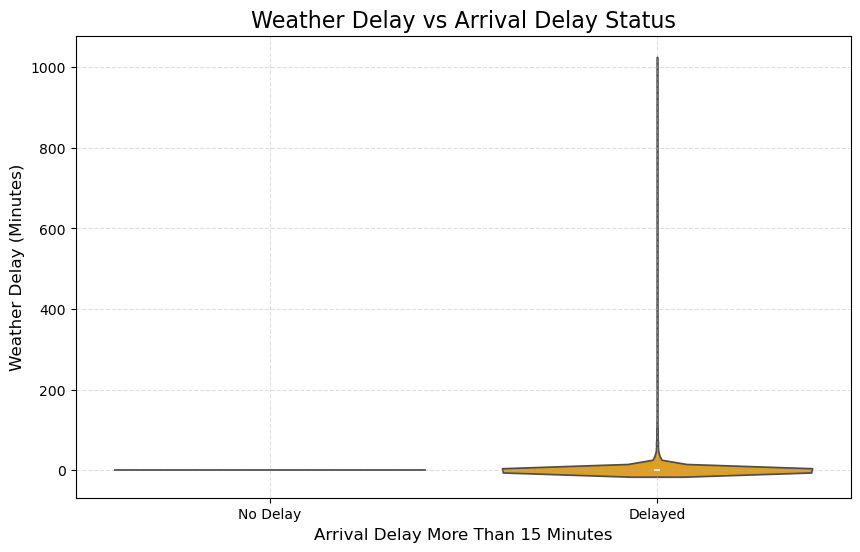

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Figure
plt.figure(figsize=(10,6))

# Violin Plot
sns.violinplot(
    x='Arr_Del_morethan15',
    y='WeatherDelay',
    data=df,
    palette='autumn'
)

# Title & Labels
plt.title('Weather Delay vs Arrival Delay Status', fontsize=16)

plt.xlabel('Arrival Delay More Than 15 Minutes', fontsize=12)
plt.ylabel('Weather Delay (Minutes)', fontsize=12)

plt.xticks([0,1], ['No Delay', 'Delayed'])

plt.grid(linestyle='--', alpha=0.4)

plt.show()

* Flights with **No Arrival Delay** show almost **zero Weather Delay**, indicating weather had little impact on on-time arrivals.
* For **Delayed flights**, most weather delays remain below **20 minutes**, but a few extreme cases exceed **1,000 minutes**.
* The violin plot suggests that while weather is not a common cause of delays, severe weather events can lead to exceptionally large arrival delays.


## Impact of Aircraft Turnaround Delays on Departures

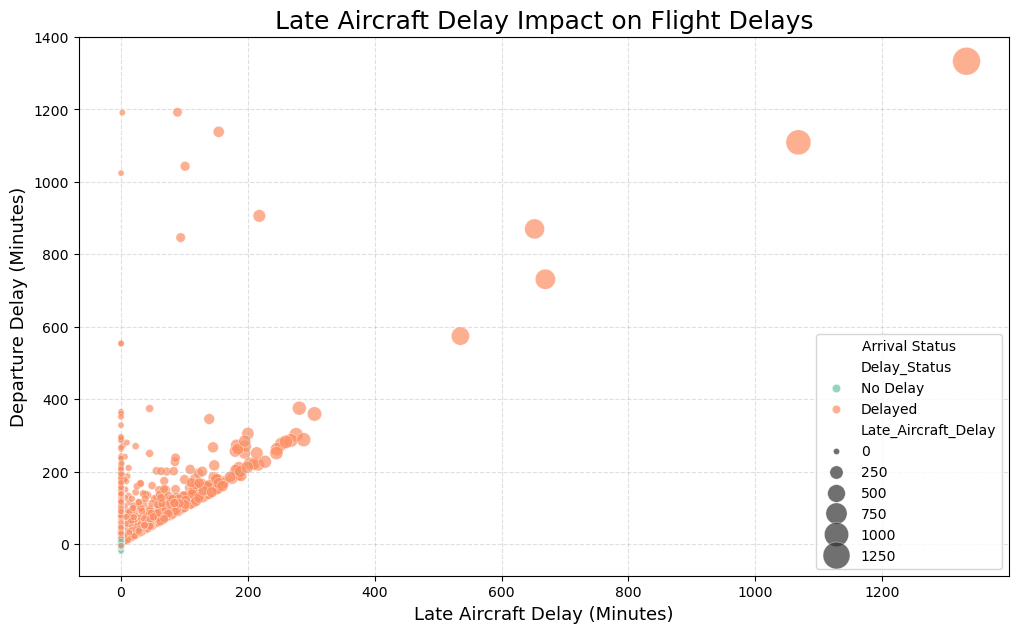

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Delay Labels
df['Delay_Status'] = df['Arr_Del_morethan15'].map({
    0: 'No Delay',
    1: 'Delayed'
})

# High-Tech Bubble Scatter Plot
plt.figure(figsize=(12,7))

sns.scatterplot(
    x='Late_Aircraft_Delay',
    y='Dep_Delay',
    hue='Delay_Status',
    size='Late_Aircraft_Delay',
    sizes=(20, 400),
    alpha=0.7,
    data=df,
    palette='Set2'
)

# Titles & Labels
plt.title('Late Aircraft Delay Impact on Flight Delays', fontsize=18)

plt.xlabel('Late Aircraft Delay (Minutes)', fontsize=13)
plt.ylabel('Departure Delay (Minutes)', fontsize=13)

plt.grid(linestyle='--', alpha=0.4)

plt.legend(title='Arrival Status')

plt.show()


* Most flights have **Late Aircraft Delays below 300 minutes**, with corresponding **Departure Delays generally under 400 minutes**, indicating a moderate impact on operations.
* A clear positive relationship exists, where higher **Late Aircraft Delays** tend to result in higher **Departure Delays**, showing that aircraft arrival issues propagate to future flights.
* Several extreme outliers are present, with **Late Aircraft Delays exceeding 1,000 minutes** and **Departure Delays reaching nearly 1,350 minutes**, highlighting severe scheduling disruptions.


## Flights departing at certain scheduled times show a higher concentration of delays.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\1376365267.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20104\1376365267.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


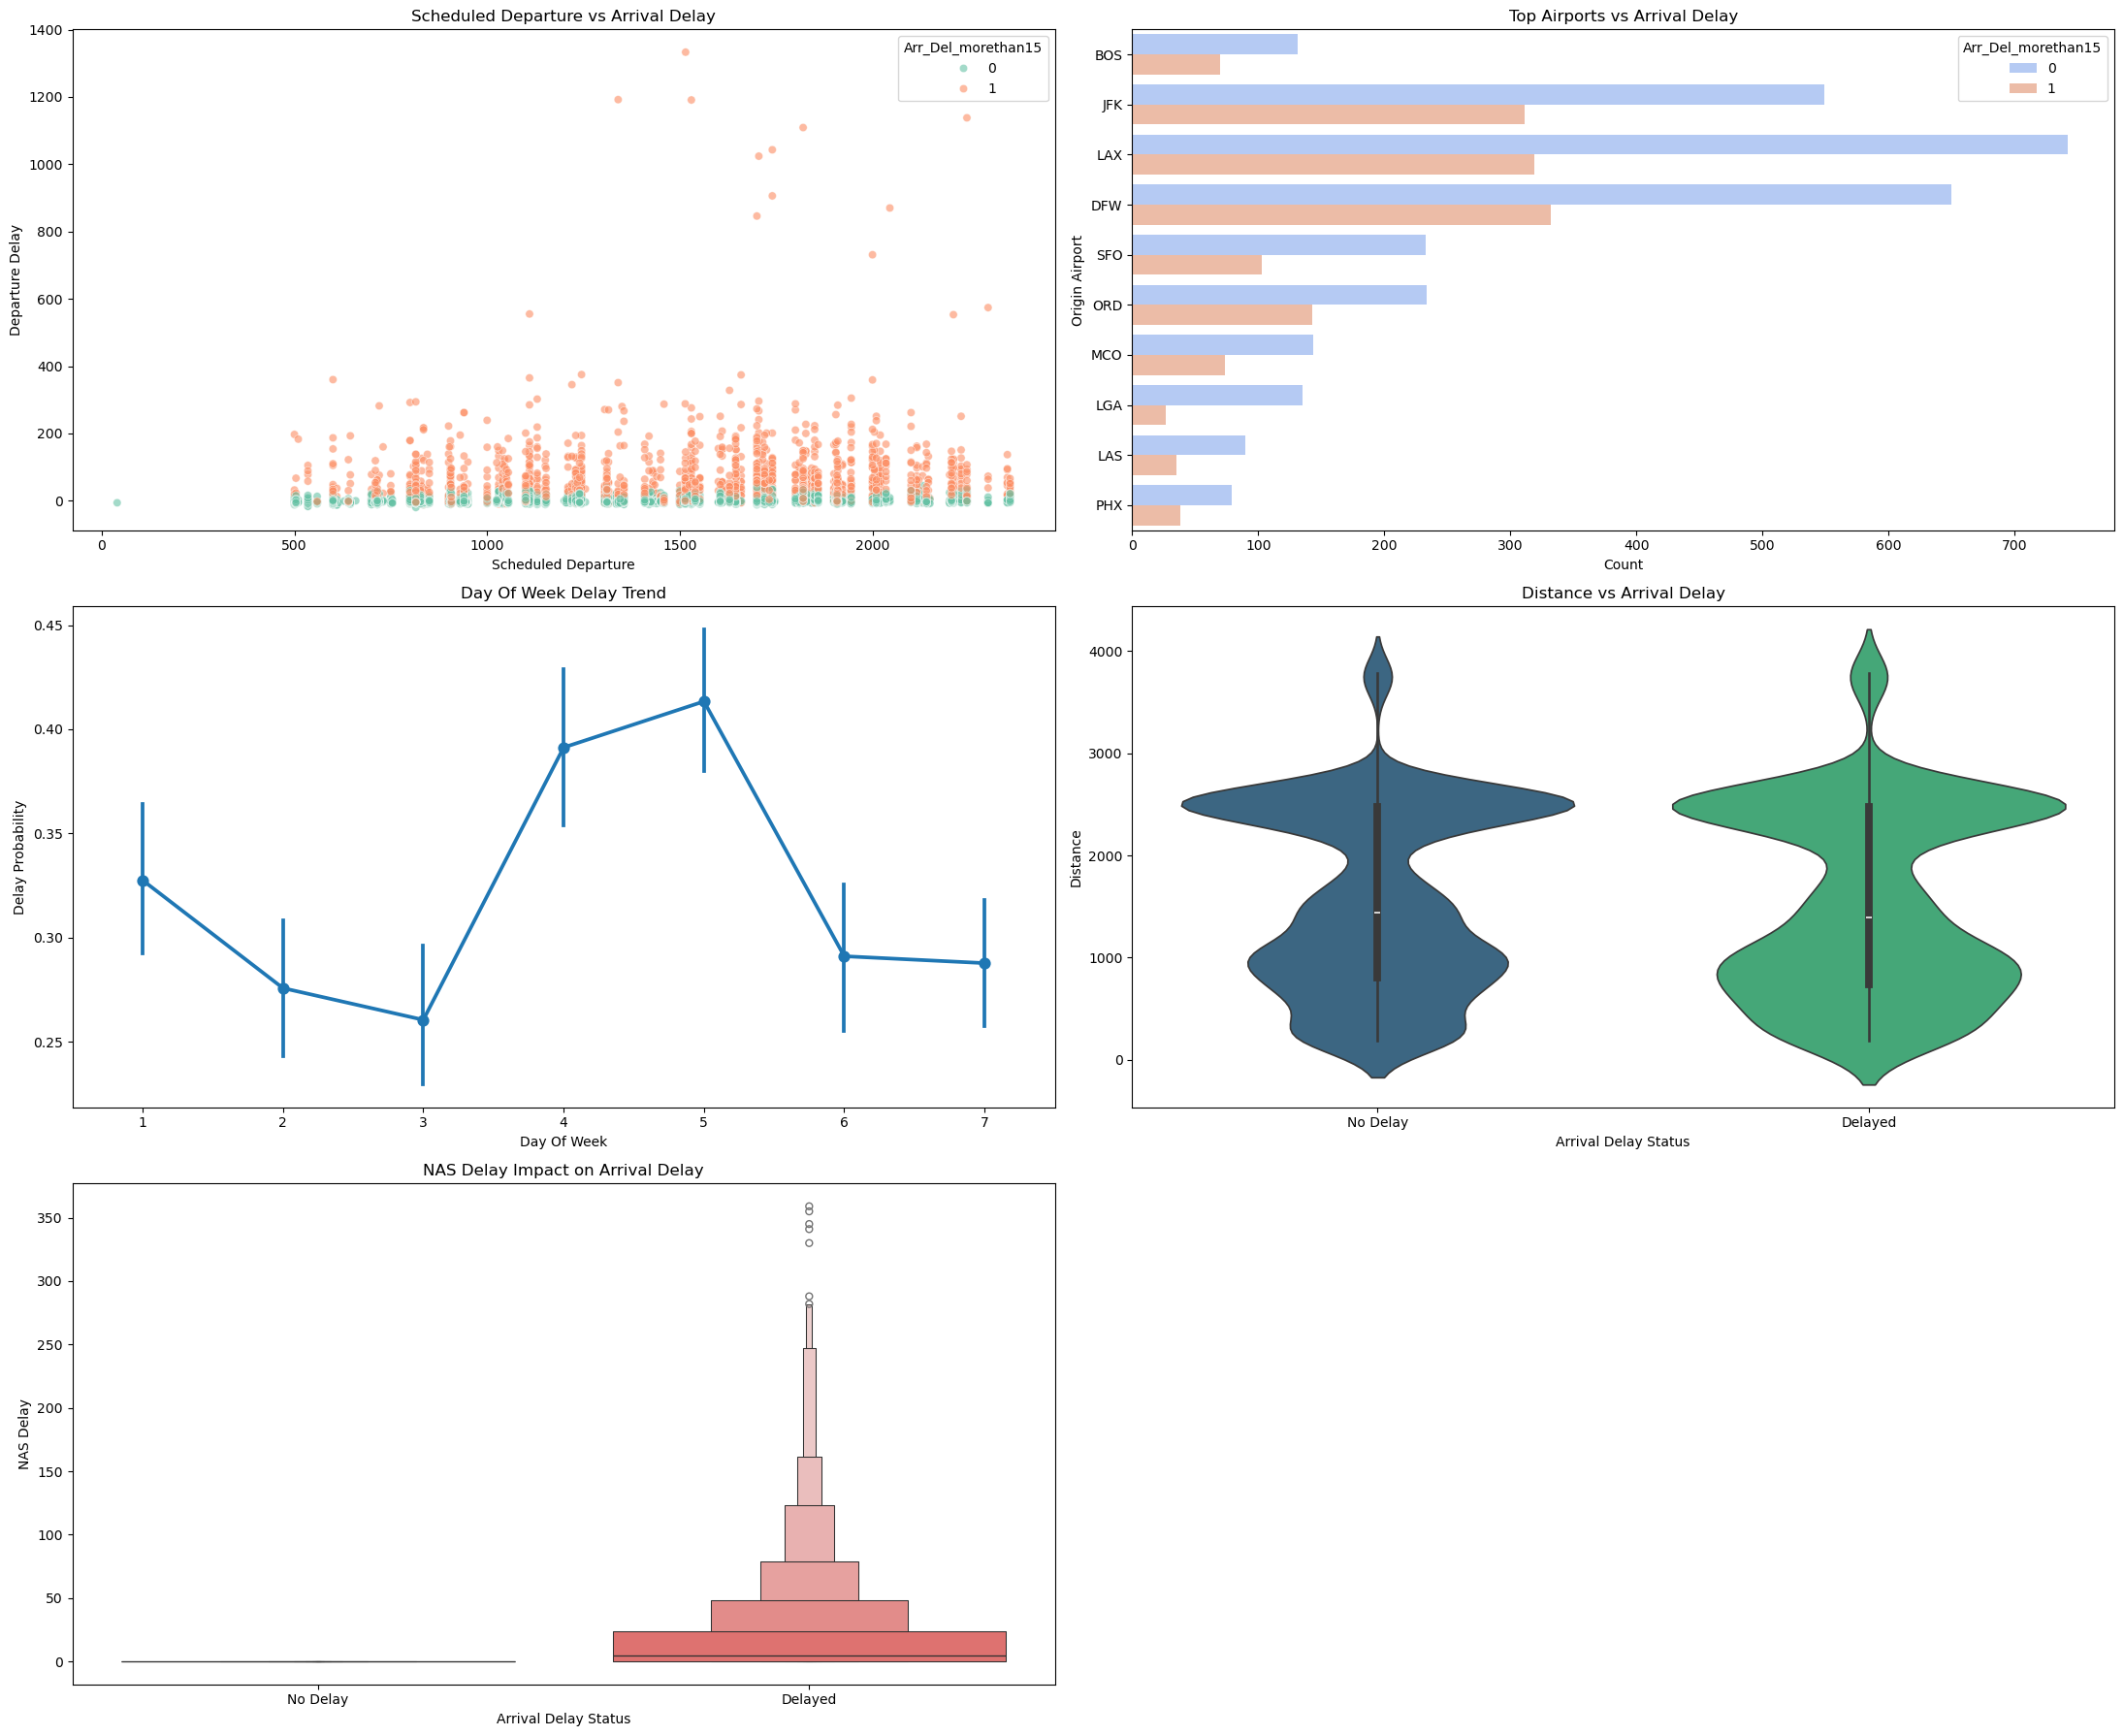

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Figure
plt.figure(figsize=(22,18))

# ---------------------------------------------------
# 1. Scheduled_Departure vs Arr_Del_morethan15
# Hexbin Style Scatter
# ---------------------------------------------------

plt.subplot(3,2,1)

sns.scatterplot(
    x='Scheduled_Departure',
    y='Dep_Delay',
    hue='Arr_Del_morethan15',
    data=df,
    palette='Set2',
    alpha=0.6
)

plt.title('Scheduled Departure vs Arrival Delay')
plt.xlabel('Scheduled Departure')
plt.ylabel('Departure Delay')

# ---------------------------------------------------
# 2. Origin_Airport vs Arr_Del_morethan15
# Horizontal Count Plot
# ---------------------------------------------------

plt.subplot(3,2,2)

top_airports = df['Origin_Airport'].value_counts().head(10).index

sns.countplot(
    y='Origin_Airport',
    hue='Arr_Del_morethan15',
    data=df[df['Origin_Airport'].isin(top_airports)],
    palette='coolwarm'
)

plt.title('Top Airports vs Arrival Delay')
plt.xlabel('Count')
plt.ylabel('Origin Airport')

# ---------------------------------------------------
# 3. DayOfWeek vs Arr_Del_morethan15
# Point Plot
# ---------------------------------------------------

plt.subplot(3,2,3)

sns.pointplot(
    x='DayOfWeek',
    y='Arr_Del_morethan15',
    data=df
)

plt.title('Day Of Week Delay Trend')
plt.xlabel('Day Of Week')
plt.ylabel('Delay Probability')

# ---------------------------------------------------
# 4. Distance vs Arr_Del_morethan15
# Violin Plot
# ---------------------------------------------------

plt.subplot(3,2,4)

sns.violinplot(
    x='Arr_Del_morethan15',
    y='Distance',
    data=df,
    palette='viridis'
)

plt.title('Distance vs Arrival Delay')
plt.xlabel('Arrival Delay Status')
plt.ylabel('Distance')

plt.xticks([0,1], ['No Delay', 'Delayed'])

# ---------------------------------------------------
# 5. NAS_Delay vs Arr_Del_morethan15
# Boxen Plot
# ---------------------------------------------------

plt.subplot(3,2,5)

sns.boxenplot(
    x='Arr_Del_morethan15',
    y='NAS_Delay',
    data=df,
    palette='magma'
)

plt.title('NAS Delay Impact on Arrival Delay')
plt.xlabel('Arrival Delay Status')
plt.ylabel('NAS Delay')

plt.xticks([0,1], ['No Delay', 'Delayed'])

# ---------------------------------------------------
# Layout
# ---------------------------------------------------

plt.tight_layout()

# Show Graphs
plt.show()

* **Day 5 has the highest delay probability (~41%)**, while **Day 3 has the lowest (~26%)**, indicating delays vary significantly across the week.
* **JFK, LAX, and DFW** record the highest number of arrival delays, with delayed flights far exceeding on-time flights at these busy airports.
* Flights with **NAS (National Airspace System) delays** show substantially higher delay times, while flights without arrival delays have almost no NAS-related delay impact.
* The **distance distribution is similar for delayed and non-delayed flights**, suggesting that flight distance alone is not a strong predictor of arrival delays.


# *Multivariate analysis:*

## Multivariate Analysis of Departure and Late Aircraft Delays

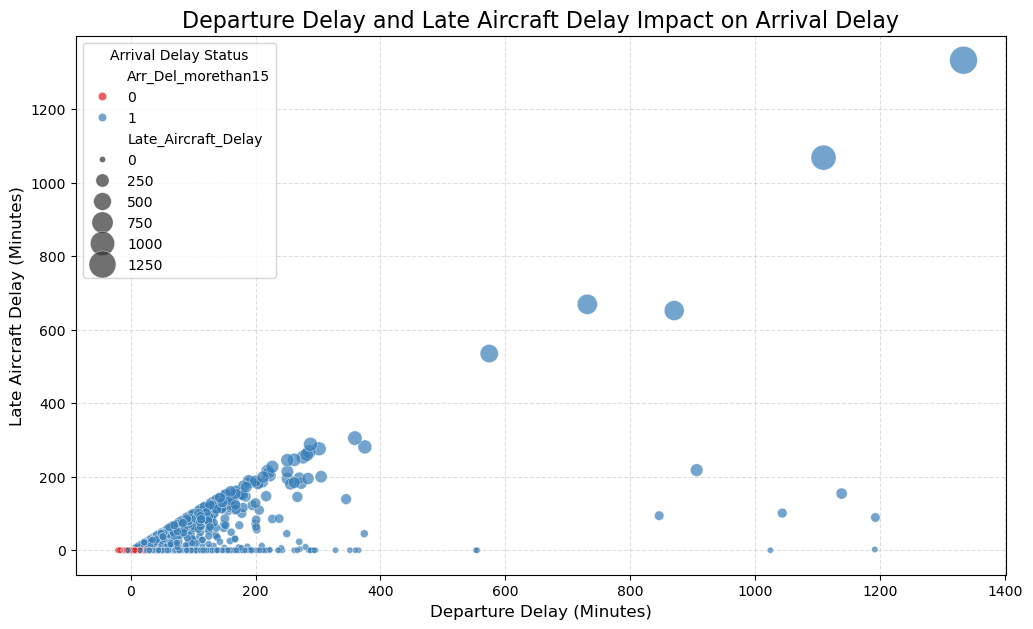

In [17]:
plt.figure(figsize=(12,7))

# Multivariate Analysis
# Dep_Delay + Late_Aircraft_Delay + Arr_Del_morethan15

sns.scatterplot(
    x='Dep_Delay',
    y='Late_Aircraft_Delay',
    hue='Arr_Del_morethan15',
    size='Late_Aircraft_Delay',
    sizes=(20,400),
    alpha=0.7,
    palette='Set1',
    data=df
)

# Title & Labels
plt.title(
    'Departure Delay and Late Aircraft Delay Impact on Arrival Delay',
    fontsize=16
)

plt.xlabel('Departure Delay (Minutes)', fontsize=12)
plt.ylabel('Late Aircraft Delay (Minutes)', fontsize=12)

plt.legend(title='Arrival Delay Status')

plt.grid(linestyle='--', alpha=0.4)

plt.show()

* Most flights with **Arrival Delay > 15 minutes** are associated with both **higher Departure Delays and Late Aircraft Delays**, showing a strong positive relationship between these factors.
* The majority of observations are concentrated below **300 minutes** for both delay types, while a few extreme cases exceed **1,300 minutes**, indicating severe operational disruptions.
* Larger bubble sizes (higher Late Aircraft Delay values) are mostly found in the delayed category, suggesting that late incoming aircraft are a major contributor to significant arrival delays.


## Flights with higher carrier and weather delays often exhibit larger NAS delays, indicating that multiple delay factors can occur simultaneously.

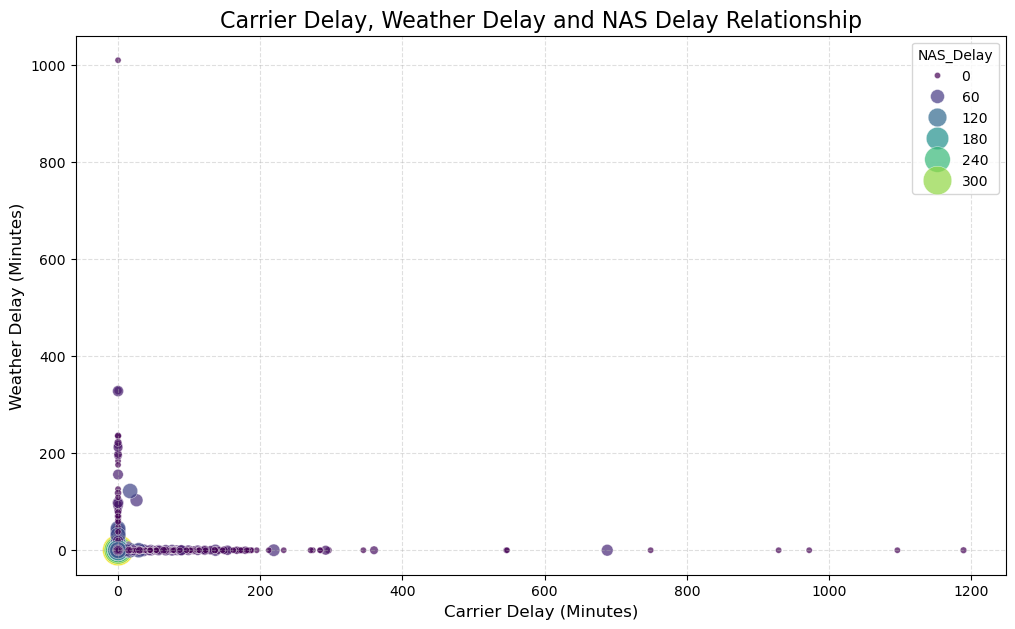

In [18]:

# Create Figure
plt.figure(figsize=(12,7))

# Multivariate Analysis
# Carrier_Delay + WeatherDelay + NAS_Delay

sns.scatterplot(
    x='Carrier_Delay',
    y='WeatherDelay',
    size='NAS_Delay',
    hue='NAS_Delay',
    sizes=(20,500),
    palette='viridis',
    alpha=0.7,
    data=df
)

# Title & Labels
plt.title(
    'Carrier Delay, Weather Delay and NAS Delay Relationship',
    fontsize=16
)

plt.xlabel('Carrier Delay (Minutes)', fontsize=12)
plt.ylabel('Weather Delay (Minutes)', fontsize=12)

plt.grid(linestyle='--', alpha=0.4)

plt.show()

* Most flights experienced minimal Carrier, Weather, and NAS delays, with data points densely clustered near zero delay values.
* A few extreme outliers show severe disruptions, with Carrier Delays reaching nearly 1200 minutes and Weather Delays exceeding 1000 minutes.
* No strong relationship is observed between Carrier Delay and Weather Delay, indicating that these delays are influenced by different operational factors.


## Combined Effect of Departure and Aircraft Delays on Arrivals

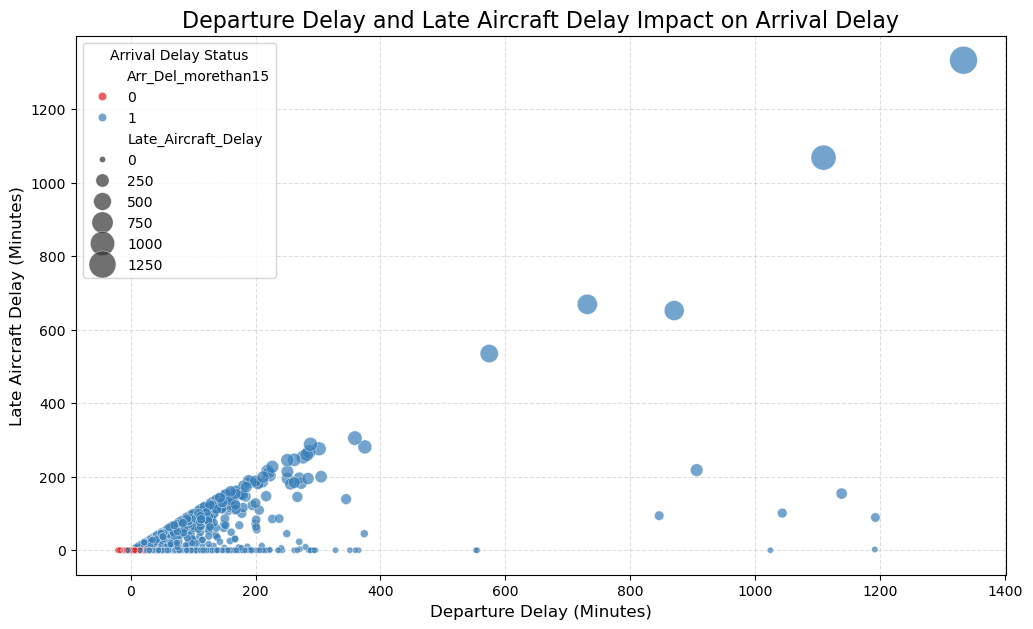

In [19]:

# Create Figure
plt.figure(figsize=(12,7))

# Multivariate Analysis
# Dep_Delay + Late_Aircraft_Delay + Arr_Del_morethan15

sns.scatterplot(
    x='Dep_Delay',
    y='Late_Aircraft_Delay',
    hue='Arr_Del_morethan15',
    size='Late_Aircraft_Delay',
    sizes=(20,400),
    alpha=0.7,
    palette='Set1',
    data=df
)

# Title & Labels
plt.title(
    'Departure Delay and Late Aircraft Delay Impact on Arrival Delay',
    fontsize=16
)

plt.xlabel('Departure Delay (Minutes)', fontsize=12)
plt.ylabel('Late Aircraft Delay (Minutes)', fontsize=12)

plt.legend(title='Arrival Delay Status')

plt.grid(linestyle='--', alpha=0.4)

plt.show()

* Most flights experienced relatively low delays, with the highest concentration of observations occurring below **200 minutes of Departure Delay** and **150 minutes of Late Aircraft Delay**.
* A clear positive relationship is visible, as flights with higher Departure Delays (up to **1350 minutes**) generally show higher Late Aircraft Delays (up to **1330 minutes**).
* A few extreme outliers exceed **1000 minutes** in both delay categories, indicating rare but severe operational disruptions that significantly impact arrival performance.


## Delay Density Pattern in Flight Operations

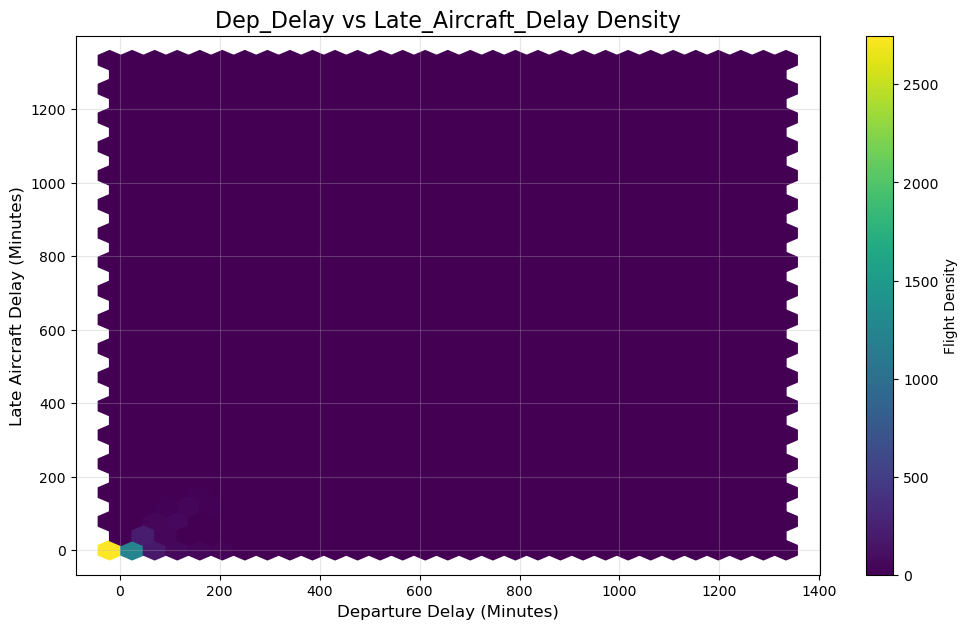

In [20]:
df['Delay_Status'] = df['Arr_Del_morethan15'].map({
    0: 'No Delay',
    1: 'Delayed'
})

# Create Figure
plt.figure(figsize=(12,7))

# Simple & Unique Hexbin Graph

plt.hexbin(
    df['Dep_Delay'],
    df['Late_Aircraft_Delay'],
    gridsize=30,
    cmap='viridis'
)

# Color Bar
cb = plt.colorbar()
cb.set_label('Flight Density')

# Title & Labels
plt.title(
    'Dep_Delay vs Late_Aircraft_Delay Density',
    fontsize=16
)

plt.xlabel('Departure Delay (Minutes)', fontsize=12)
plt.ylabel('Late Aircraft Delay (Minutes)', fontsize=12)

plt.grid(alpha=0.3)

plt.show()

* The highest flight density is concentrated near **0–50 minutes Departure Delay** and **0–20 minutes Late Aircraft Delay**, indicating that most flights experienced minimal delays.
* Flight density decreases rapidly as delays increase, with very few observations beyond **200 minutes Departure Delay** and **100 minutes Late Aircraft Delay**.
* A small number of extreme outliers extend up to **1350 minutes** in both delay categories, but these represent rare events with very low occurrence density.


## Carrier Delay Trends Across the Week

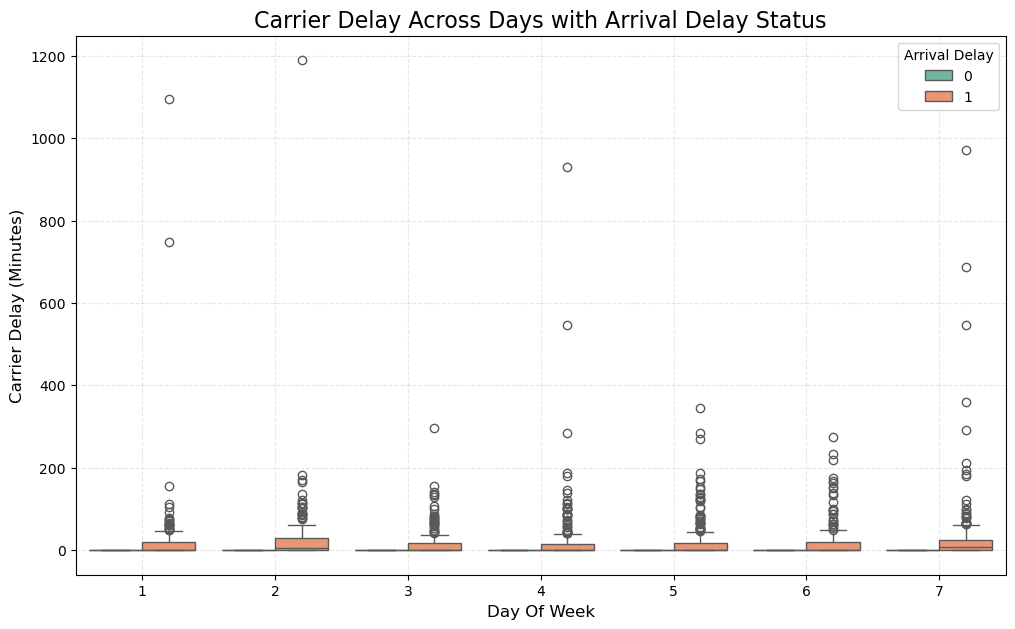

In [21]:
#Create Figure
plt.figure(figsize=(12,7))

# Multivariate Analysis
# DayOfWeek + Carrier_Delay + Arr_Del_morethan15

sns.boxplot(
    x='DayOfWeek',
    y='Carrier_Delay',
    hue='Arr_Del_morethan15',
    data=df,
    palette='Set2'
)

# Title & Labels
plt.title(
    'Carrier Delay Across Days with Arrival Delay Status',
    fontsize=16
)

plt.xlabel('Day Of Week', fontsize=12)
plt.ylabel('Carrier Delay (Minutes)', fontsize=12)

plt.grid(linestyle='--', alpha=0.3)

plt.legend(title='Arrival Delay')

plt.show()

* Carrier Delay remains low for most flights across all **7 days of the week**, with median delays close to **0–10 minutes**.
* Significant outliers are observed on multiple days, with the highest Carrier Delays reaching approximately **1,200 minutes on Day 2**, **1,100 minutes on Day 1**, and **970 minutes on Day 7**.
* Flights with **Arrival Delay > 15 minutes** show a wider spread and higher Carrier Delays, indicating that carrier-related issues contribute substantially to late arrivals.


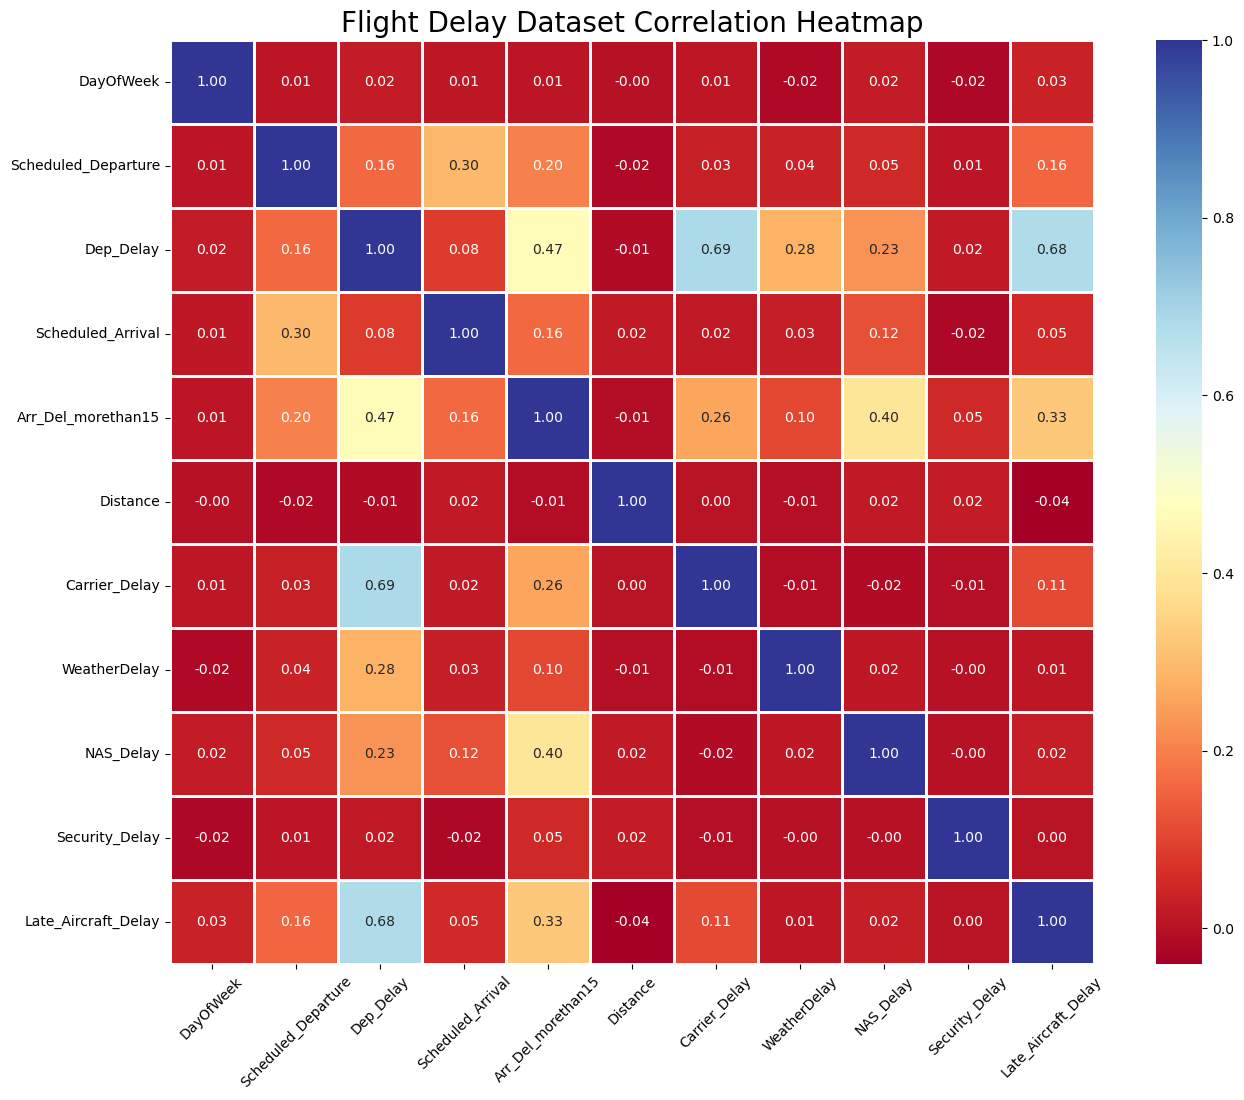

In [22]:
# Select Only Numeric Columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create Figure
plt.figure(figsize=(16,12))

# Heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f',
    square=True,
    linewidths=1,
    cbar=True
)

# Title
plt.title(
    'Flight Delay Dataset Correlation Heatmap',
    fontsize=20
)

# Rotate Labels
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Show Plot
plt.show()

* **Departure Delay shows the strongest positive correlation with Carrier Delay (0.69) and Late Aircraft Delay (0.68)**, indicating that delayed departures are a major contributor to overall flight delays.
* **Arrival Delay (>15 min) is moderately correlated with Departure Delay (0.47) and NAS Delay (0.40)**, suggesting that both departure issues and air traffic system delays significantly affect arrival performance.
* **Day of Week and Distance have near-zero correlations with most variables (≈ -0.02 to 0.03)**, indicating that flight delays are largely independent of travel distance and the day on which the flight operates.


# Executive Summary

Flight delay prediction is a critical problem in aviation analytics because delays affect airline operations, airport efficiency, and passenger satisfaction. This report provides a data-driven evaluation of flight delay behavior using flight timing variables, delay-cause features, airport-level information, and schedule-based attributes.

The analysis shows that delay patterns are not driven by a single factor. Instead, they are shaped by a combination of departure delays, carrier-related issues, late aircraft arrivals, NAS congestion, and weather disruptions. By identifying the strongest delay drivers and the most affected flight segments, this report highlights clear operational patterns that can support better delay management and predictive modeling.

# Methodology & Data Preprocessing

To ensure reliable exploratory analysis, a structured preprocessing pipeline was applied before visual exploration and correlation analysis.

## Column Removal and Leakage Prevention

Several columns were removed because they provided little analytical value or could cause target leakage. **Cancelled**, **Diverted**, and **Top_Carriers** were mostly constant and did not contribute meaningful variation. **ArrDelay** was removed because it was directly used to create the target variable **Arr_Del_morethan15**, which would create leakage. **ArrTime** and **DepTime** were also excluded because they may reveal outcome information too directly and reduce the fairness of predictive analysis.

## Target Variable Definition

The target variable, **Arr_Del_morethan15**, was used as the main outcome measure because it indicates whether a flight arrived more than 15 minutes late. This makes it a strong and practical binary target for delay classification and operational forecasting.

## Data Structure Standardization

The dataset contains both numerical and categorical variables, including flight timing, airport identifiers, delay causes, distance, and day-of-week information. Column naming and feature interpretation were kept consistent to support clear EDA and modeling workflow.

# Key Findings & Behavioral Insights

## A. Core Dataset Composition (Univariate Analysis)

### Delay Class Distribution

The target variable shows a moderate class imbalance. Around **3,250 flights arrived on time**, while nearly **1,550 flights were delayed by more than 15 minutes**. This suggests that most flights performed well, but a meaningful delayed subset still exists and requires attention.

### Departure Delay Distribution

Departure delays are heavily right-skewed. Most flights had low departure delays, mainly between **0 and 50 minutes**, with the highest concentration near zero. However, a small number of extreme outliers reached nearly **1,300 minutes**, showing that rare but severe disruptions exist in the data.

### Weekly and Airport Traffic Patterns

Flight operations were higher on **Day 5** and **Day 7**, with roughly **780–790 flights** on those days. Airports such as **LAX** and **DFW** handled the highest flight volume, indicating that congestion at major hubs may play an important role in delay behavior.

## B. Delay Causes and Operational Friction

### Cause-Based Delay Distribution

**Carrier Delay**, **Weather Delay**, **NAS Delay**, and **Late Aircraft Delay** all show strong right-skewed distributions with many low-delay observations and a few severe outliers. This indicates that most flights experience minimal disruption, but a small set of flights faces major operational issues.

### Delay Component Interpretation

Carrier-related delays and late aircraft delays appear especially important because they reflect operational propagation across the flight network. Weather delays and NAS delays occur less frequently for most flights, but when they do occur, they can create substantial disruptions.

## C. Flight Delay Status and Operational Relationship

### Departure Delay as the Strongest Indicator

The bivariate analysis shows a clear relationship between departure delay and arrival delay status. Flights with low departure delays mostly arrived on time, while delayed flights showed much higher departure delay values. This confirms that departure delay is one of the strongest indicators of arrival delay.

### Carrier Delay and Departure Delay

Carrier delay and departure delay show a positive relationship. Most flights cluster below **200 minutes** for both variables, but a few extreme observations show severe disruptions. This suggests that airline-related operational problems strongly influence departure performance.

### Weather Delay and Arrival Performance

Flights with no arrival delay show almost no weather delay, while delayed flights show a wider spread of weather-related disruption. Although weather is not the dominant cause for most flights, extreme weather cases can create very large delay values.

### Late Aircraft Delay Propagation

Late aircraft delay has a strong influence on departure delay. Flights with higher late aircraft delays usually show higher departure delays as well. This indicates that delays from previous aircraft can propagate through the schedule and affect future operations.

# Advanced Multivariate Deep-Dives

## Delay Probability by Day of Week

Day 5 has the highest delay probability at around **41%**, while Day 3 has the lowest at around **26%**. This shows that delay likelihood varies across the week, possibly due to traffic volume, operational pressure, or schedule structure.

## Airport-Level Delay Concentration

**JFK**, **LAX**, and **DFW** record the highest number of arrival delays, with delayed flights far exceeding on-time flights at these busy airports. This suggests that large hub airports may require more delay mitigation and congestion management.

## Departure Delay and Late Aircraft Delay Combined Effect

Flights with both higher departure delays and late aircraft delays are much more likely to arrive more than **15 minutes late**. The majority of observations remain below **300 minutes** for both metrics, but extreme cases exceed **1,300 minutes**, reflecting severe operational disruption.

## Carrier, Weather, and NAS Delay Interaction

Carrier, weather, and NAS delays are all clustered near zero for most flights, but a few outliers show very large disruptions. Carrier Delay and Weather Delay do not show a strong direct relationship, suggesting that they are driven by different operational conditions. However, both can contribute to high NAS-related delay outcomes.

## Delay Density Pattern

The hexbin analysis shows the highest density at low delay values, especially around **0–50 minutes** for departure delay and **0–20 minutes** for late aircraft delay. Density falls quickly as delays increase, confirming that extreme delays are rare but impactful.

## Weekly Carrier Delay Trends

Carrier delay remains low for most flights across all seven days of the week, with median values near **0–10 minutes**. However, several days show extreme outliers, indicating that carrier issues can spike sharply under specific conditions.

## Correlation Insights

Departure delay has the strongest positive correlation with **Carrier Delay (0.69)** and **Late Aircraft Delay (0.68)**. Arrival delay greater than 15 minutes is moderately correlated with **Departure Delay (0.47)** and **NAS Delay (0.40)**. In contrast, **Day Of Week** and **Distance** show near-zero correlation with most delay variables, suggesting that delay behavior is more operational than route-length driven.

# Strategic Recommendations

## 1. Prioritize Departure Delay Monitoring

Since departure delay is the strongest signal of arrival delay, airlines should monitor departure performance in real time and flag flights that exceed early delay thresholds. This can help identify high-risk flights before arrival disruption occurs.

## 2. Improve Late Aircraft Turnaround Management

Late aircraft delay is a major propagation factor. Airlines should strengthen turnaround scheduling, aircraft rotation planning, and buffer-time allocation to reduce the spread of downstream delays.

## 3. Focus on Hub Airport Congestion

Because airports like **LAX**, **DFW**, and **JFK** show high delay concentration, operational teams should focus on congestion reduction, gate management, and traffic coordination at these major hubs.

## 4. Strengthen Weather and NAS Response Planning

Weather and NAS delays are less common but can become severe when they occur. Contingency planning, weather-triggered rescheduling, and airspace coordination can reduce the impact of these disruptions.

## 5. Use Delay-Cause Features for Predictive Modeling

Carrier Delay, NAS Delay, Weather Delay, and Late Aircraft Delay should be treated as key predictive variables in any delay classification model since they explain much of the observed delay variation.

# Business Conclusion

The analysis shows that flight delays are mainly driven by operational factors rather than flight distance or day alone. Departure delay is the strongest indicator of late arrival, while carrier delay and late aircraft delay also play major roles in delay propagation. NAS and weather delays contribute less frequently but can create severe disruptions when they occur. Busy airports and certain days of the week experience higher delay concentration, which suggests that congestion and scheduling pressure are important operational risks. Overall, airlines should focus on early delay detection, turnaround efficiency, and hub-level congestion control to reduce arrival delays and improve on-time performance.
